In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target column
df["species"] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# Inspect the dataset

print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [3]:
# Statistical summary

df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Check for missing values and class distribution

print("Missing Values:")
print(df.isnull().sum())

print("\nSpecies Distribution:")
print(df["species"].value_counts().sort_index())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Species Distribution:
species
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
# Convert species numbers to flower names

species_names = {
    0: "setosa",
    1: "versicolor",
    2: "virginica"
}

df["species_name"] = df["species"].map(species_names)

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


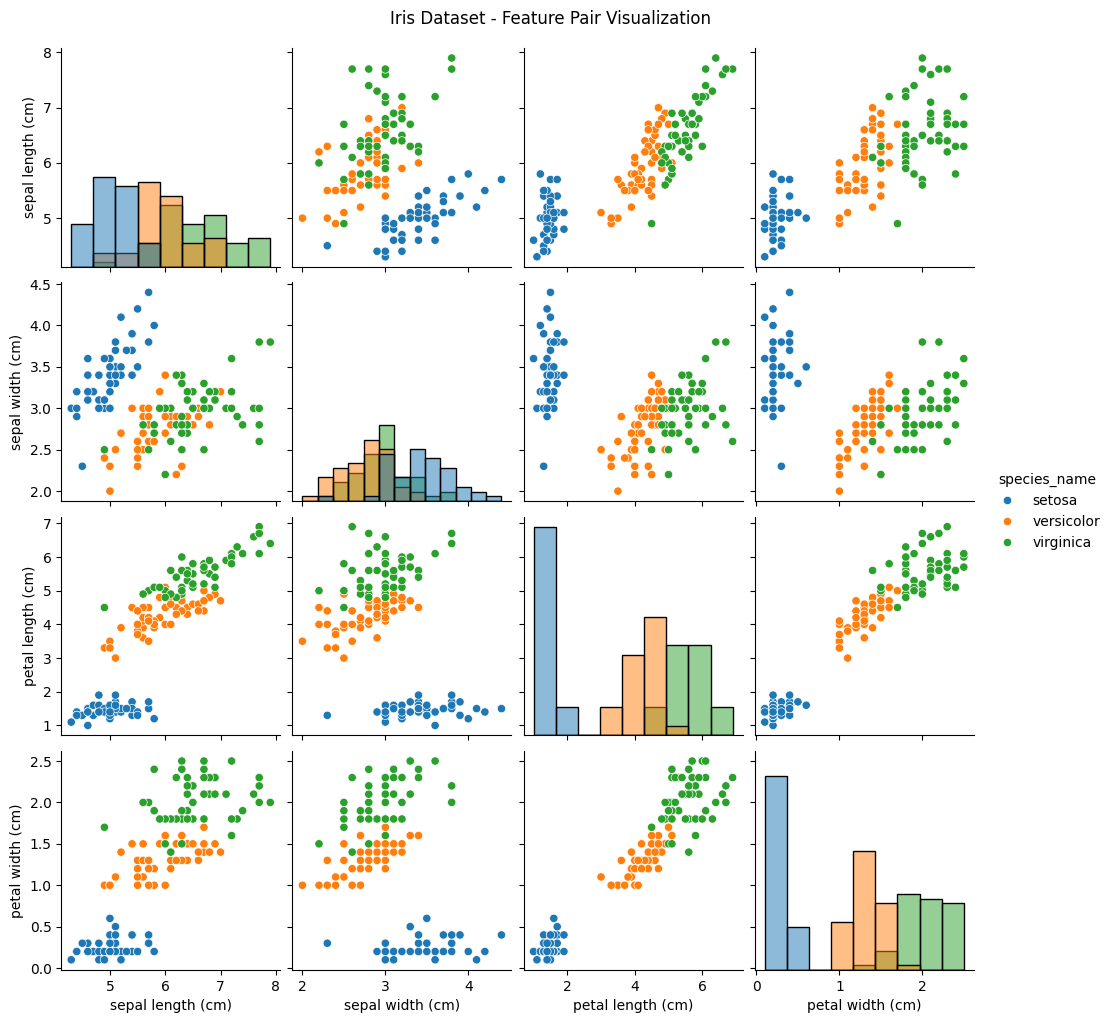

In [6]:
# Feature pair visualization

sns.pairplot(
    df,
    vars=iris.feature_names,
    hue="species_name",
    diag_kind="hist"
)

plt.suptitle("Iris Dataset - Feature Pair Visualization", y=1.02)

plt.savefig(
    "../outputs/feature_pair_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
# Prepare features and target for classification

X = df[iris.feature_names]
y = df["species"]

print("Features:")
print(X.columns.tolist())

print("\nTarget classes:")
print(sorted(y.unique()))

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [8]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [9]:
# Train Logistic Regression classifier

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", round(logistic_accuracy, 4))
print("Logistic Regression Accuracy (%):", round(logistic_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 0.9667
Logistic Regression Accuracy (%): 96.67 %


In [10]:
# Train Decision Tree classifier

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = decision_tree_model.predict(X_test)

# Calculate accuracy
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", round(tree_accuracy, 4))
print("Decision Tree Accuracy (%):", round(tree_accuracy * 100, 2), "%")

Decision Tree Accuracy: 0.9333
Decision Tree Accuracy (%): 93.33 %


In [11]:
# Compare classifier accuracy

accuracy_comparison = pd.DataFrame({
    "Classifier": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy
    ]
})

accuracy_comparison["Accuracy (%)"] = (
    accuracy_comparison["Accuracy"] * 100
)

accuracy_comparison.round(2)

,Classifier,Accuracy,Accuracy (%)
0,Logistic Regression,0.97,96.67
1,Decision Tree,0.93,93.33


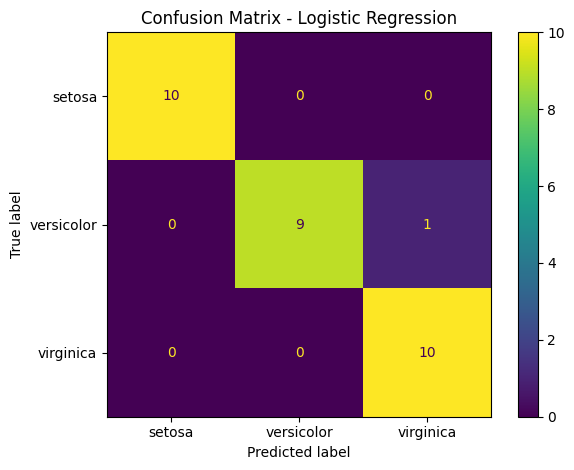

In [12]:
# Confusion Matrix - Logistic Regression

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()

plt.savefig(
    "../outputs/confusion_matrix_logistic_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

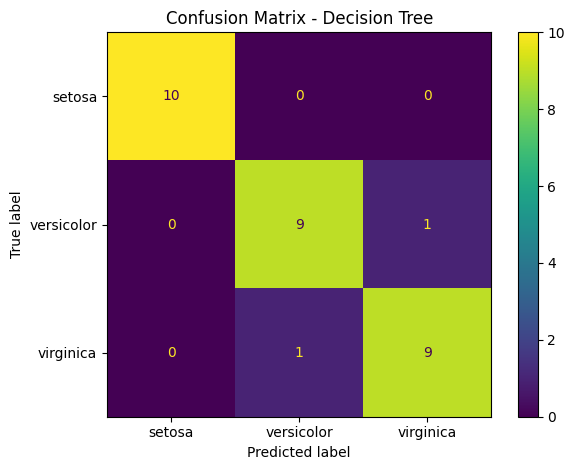

In [13]:
# Confusion Matrix - Decision Tree

cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()

plt.savefig(
    "../outputs/confusion_matrix_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# Identify misclassified samples for both models

results = pd.DataFrame({
    "Actual": y_test,
    "Logistic Prediction": y_pred_logistic,
    "Decision Tree Prediction": y_pred_tree
})

# Convert numeric labels to flower names
results["Actual Species"] = results["Actual"].map(species_names)
results["Logistic Prediction Species"] = results["Logistic Prediction"].map(species_names)
results["Decision Tree Prediction Species"] = results["Decision Tree Prediction"].map(species_names)

# Show only samples misclassified by at least one model
misclassified = results[
    (results["Actual"] != results["Logistic Prediction"]) |
    (results["Actual"] != results["Decision Tree Prediction"])
]

misclassified[
    [
        "Actual Species",
        "Logistic Prediction Species",
        "Decision Tree Prediction Species"
    ]
]

,Actual Species,Logistic Prediction Species,Decision Tree Prediction Species
134,virginica,virginica,versicolor
77,versicolor,virginica,virginica


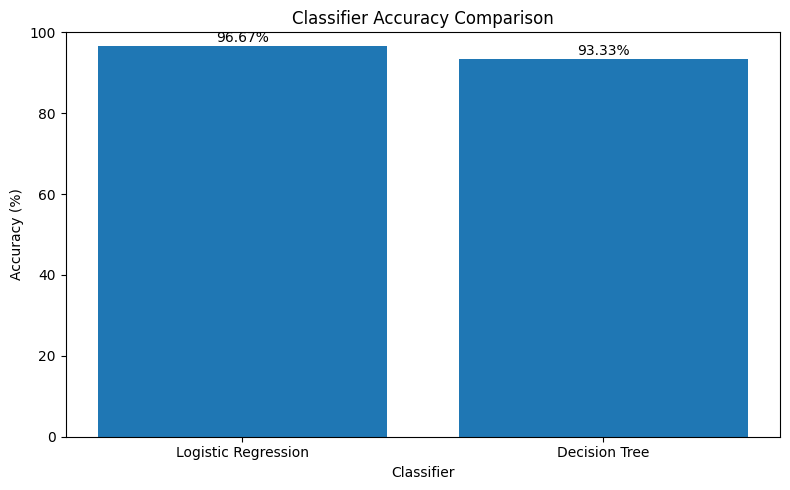

In [15]:
# Visualize and save classifier accuracy comparison

plt.figure(figsize=(8, 5))

plt.bar(
    accuracy_comparison["Classifier"],
    accuracy_comparison["Accuracy (%)"]
)

plt.xlabel("Classifier")
plt.ylabel("Accuracy (%)")
plt.title("Classifier Accuracy Comparison")
plt.ylim(0, 100)

# Display accuracy values above bars
for i, value in enumerate(accuracy_comparison["Accuracy (%)"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
import joblib

# Save trained classification models

logistic_model_path = "../models/logistic_regression_iris_model.pkl"
decision_tree_model_path = "../models/decision_tree_iris_model.pkl"

joblib.dump(logistic_model, logistic_model_path)
joblib.dump(decision_tree_model, decision_tree_model_path)

print("Logistic Regression model saved at:", logistic_model_path)
print("Decision Tree model saved at:", decision_tree_model_path)

Logistic Regression model saved at: ../models/logistic_regression_iris_model.pkl
Decision Tree model saved at: ../models/decision_tree_iris_model.pkl
